# SLI y experiencia de usuario

Este cuaderno muestra si la experiencia de carga de formularios esta dentro del objetivo esperado y como evoluciona en el tiempo.

In [1]:
import sys
from pathlib import Path

NOTEBOOK_CWD = Path.cwd()
candidate_roots = [
    NOTEBOOK_CWD,
    NOTEBOOK_CWD.parent if NOTEBOOK_CWD.name == 'notebooks' else NOTEBOOK_CWD,
    NOTEBOOK_CWD / 'observability' / 'd365-fo-observability',
]
PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / 'src' / 'kql_runner.py').exists() and (candidate / 'queries').exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise RuntimeError('No se pudo localizar observability/d365-fo-observability desde el directorio actual')
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from kql_runner import build_client, load_config, load_kql, metric_snapshot, plot_timeseries, run_kql, set_analyst_theme

config = load_config()
client = build_client(config=config)
SLI_DAYS = config['query_days']
set_analyst_theme()

In [2]:
df_summary = run_kql(client, load_kql('10_sli_executive_summary.kql'), days=SLI_DAYS, name='SLI executive summary', config=config)
df_under_target = run_kql(client, load_kql('11_sli_forms_under_target.kql'), days=SLI_DAYS, name='SLI forms under target', config=config)
df_timeseries = run_kql(client, load_kql('12_sli_forms_under_target_timeseries.kql'), days=SLI_DAYS, name='SLI timeseries', config=config)

display(df_summary)
if not df_summary.empty:
    display(metric_snapshot({
        'Form loads': int(df_summary.loc[0, 'FormLoads']),
        'Avg form load (s)': float(df_summary.loc[0, 'AvgFormLoadSeconds']),
        'P95 form load (s)': float(df_summary.loc[0, 'P95FormLoadSeconds']),
        'Exceptions': int(df_summary.loc[0, 'Exceptions']),
        'Slow queries': int(df_summary.loc[0, 'SlowQueries']),
    }))
display(df_under_target)
display(df_timeseries.tail(24))

Ejecutando: SLI executive summary
Filas devueltas: 1
Ejecutando: SLI forms under target
Filas devueltas: 1
Ejecutando: SLI timeseries
Filas devueltas: 39


,FormLoads,AvgFormLoadSeconds,P95FormLoadSeconds,Exceptions,SlowQueries
0,1329,0.52,1.86,33,0


,Metrica,Valor
0,Form loads,1329.00
1,Avg form load (s),0.52
2,P95 form load (s),1.86
3,Exceptions,33.00
4,Slow queries,0.00


,TotalFormLoads,GoodFormLoads,SLIFormsUnderTargetPercent
0,3811,3800,99.71


,timestamp,TotalFormLoads,GoodFormLoads,P95Seconds,SLIFormsUnder5sPercent
15,2026-07-03 09:00:00+00:00,126,126,1.81,100.00
16,2026-07-03 10:00:00+00:00,88,88,2.14,100.00
17,2026-07-03 11:00:00+00:00,120,120,2.02,100.00
18,2026-07-03 12:00:00+00:00,131,131,2.39,100.00
19,2026-07-03 13:00:00+00:00,27,27,2.45,100.00
20,2026-07-03 14:00:00+00:00,41,41,1.28,100.00
21,2026-07-03 15:00:00+00:00,22,22,0.64,100.00
22,2026-07-03 16:00:00+00:00,22,22,0.80,100.00
23,2026-07-05 10:00:00+00:00,10,7,19.23,70.00
24,2026-07-05 17:00:00+00:00,50,49,3.89,98.00


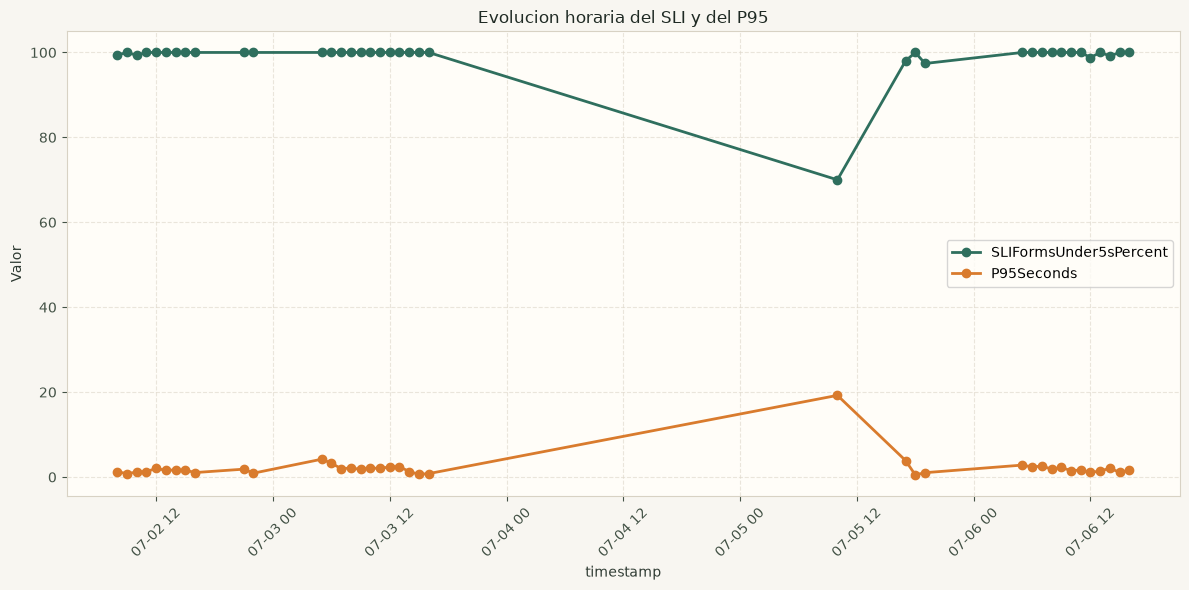

In [3]:
plot_timeseries(df_timeseries, 'timestamp', ['SLIFormsUnder5sPercent', 'P95Seconds'], 'Evolucion horaria del SLI y del P95')

## Lectura analitica

- El KPI agregado sirve para portada; la serie temporal sirve para detectar horas problemáticas.
- Si el porcentaje bajo objetivo cae cuando sube el P95, ambas metricas deberian mostrarse juntas en dashboard.
- Si hay muy poco volumen de cargas, el KPI semanal puede ser engañoso y conviene ampliar ventana o usar tabla de detalle.